In [22]:
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
import requests
import pandas as pd
from datetime import datetime, timedelta
import time
from tqdm import tqdm

def fetch_defillama_historical_prices(coin_id, start_date='2025-01-01', end_date=None, disable_tqdm=False):
    """
    Fetches daily historical prices for a given coin from DefiLlama.
    
    Parameters:
    coin_id (str): The coin identifier, e.g., "ethereum:0x9d39a5de30e57443bff2a8307a4256c8797a3497"
    start_date (str): Start date in 'YYYY-MM-DD' format (default: '2025-01-01')
    end_date (str): End date in 'YYYY-MM-DD' format; if None, uses yesterday's date (default: None)
    disable_tqdm (bool): If True, disables the progress bar (default: False)

    Returns:
    pd.DataFrame: Columns: datetime (datetime), timestamp (int), price (float)
    """
    if end_date is None:
        end_date = (datetime.now() - timedelta(days=1)).strftime('%Y-%m-%d')
    
    start_dt = datetime.strptime(start_date, '%Y-%m-%d')
    end_dt = datetime.strptime(end_date, '%Y-%m-%d')
    delta = timedelta(days=1)
    total_days = (end_dt - start_dt).days + 1

    records = []
    current_dt = start_dt
    
    with tqdm(total=total_days, desc=f"Fetching prices for {coin_id}", disable=disable_tqdm) as pbar:
        while current_dt <= end_dt:
            # Convert date to midnight UTC timestamp
            timestamp = int(current_dt.replace(hour=0, minute=0, second=0).timestamp())
            url = f"https://coins.llama.fi/prices/historical/{timestamp}/{coin_id}"
            
            try:
                response = requests.get(url)
                response.raise_for_status()
                data = response.json()
                price_data = data['coins'].get(coin_id, {})
                price = price_data.get('price')
                if price is not None:
                    records.append({
                        'datetime': current_dt,
                        'timestamp': timestamp,
                        'price': price
                    })
                else:
                    pbar.set_postfix_str(f"No price for {current_dt.date()}")
            except Exception as e:
                pbar.set_postfix_str(f"Error: {e}")
            
            time.sleep(0.2)  # Be respectful to the API
            current_dt += delta
            pbar.update(1)

            # if len(records) > 10:
            #     break

    df = pd.DataFrame(records)
    if not df.empty:
        df['datetime'] = pd.to_datetime(df['datetime'])
    return df


# Example usage
if __name__ == "__main__": 
    coin = "ethereum:0x9d39a5de30e57443bff2a8307a4256c8797a3497" # susde
    # coin = "ethereum:0x80ac24aa929eaf5013f6436cda2a7ba190f5cc0b" # syruo
    df = fetch_defillama_historical_prices(coin, start_date='2024-01-01',)
    print(df.head())

Fetching prices for ethereum:0x9d39a5de30e57443bff2a8307a4256c8797a3497: 100%|██████████| 859/859 [11:41<00:00,  1.23it/s, No price for 2025-09-01]

    datetime   timestamp     price
0 2024-03-06  1709672400  1.017699
1 2024-03-07  1709758800  1.014807
2 2024-03-08  1709845200  1.021062
3 2024-03-09  1709931600  1.022491
4 2024-03-10  1710018000  1.026256


<Axes: >

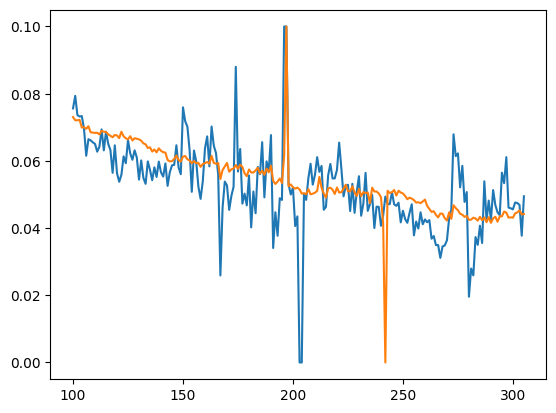

In [19]:
import pandas as pd
import numpy as np

def compute_apy_from_prices(df, rolling_window_days=None):
    """
    Compute APY from daily price data of a yield‑bearing token.

    Parameters:
    df : DataFrame with columns 'datetime' (or index) and 'price'
    rolling_window_days : int or None. If provided, returns a Series of rolling APY.

    Returns:
    - If rolling_window_days is None: overall APY (float)
    - Else: Series of rolling APY (daily granularity).
    """
    df = df.sort_values('datetime').copy()
    if df.empty:
        return np.nan if rolling_window_days is None else pd.Series(dtype=float)

    # Ensure prices are positive
    df = df[df['price'] > 0].copy()

    # ---- Overall APY ----
    start_price = df['price'].iloc[0]
    end_price = df['price'].iloc[-1]
    days = (df['datetime'].iloc[-1] - df['datetime'].iloc[0]).days
    if days <= 0:
        overall_apy = np.nan
    else:
        overall_apy = (end_price / start_price) ** (365 / days) - 1

    if rolling_window_days is None:
        return overall_apy

    # ---- Rolling APY ----
    # Daily log returns
    df['log_return'] = np.log(df['price'] / df['price'].shift(1))
    # Rolling sum of log returns over the window
    rolling_log_return = df['log_return'].rolling(window=rolling_window_days, min_periods=rolling_window_days).sum()
    # Annualize: APY = exp(rolling_log_return * (365 / window_days)) - 1
    rolling_apy = np.exp(rolling_log_return * (365 / rolling_window_days)) - 1
    rolling_apy = rolling_apy.rename('rolling_apy')
    return rolling_apy

compute_apy_from_prices(df, 7)[100:].clip(0,0.1).plot()
compute_apy_from_prices(df, 45)[100:].clip(0,0.1).plot()

In [20]:
df['apy'] = compute_apy_from_prices(df, 30)
df.to_csv("/Users/yegortrussov/Documents/ml/lending_protocols/dataset_collection/data/yb_yields/syrupusdc.csv", index=False)